<a href="https://colab.research.google.com/github/shraddhas-20/PowerPuff-Girls-Detector/blob/main/PowerPuffGirls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
'''from google.colab import files

uploaded = files.upload()'''

'from google.colab import files\n\nuploaded = files.upload()'

In [34]:
import os

zip_file = " powerpuffs.zip"

if not os.path.exists("dataset"):
    os.makedirs("dataset")

!unzip -q "{zip_file}" -d dataset


replace dataset/__MACOSX/._ powerpuffs? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [35]:
import numpy as np
import matplotlib.pyplot as plt

In [36]:
import os
import cv2
import numpy as np

dataset_path = "/content/ powerpuffs.zip"

# *Train*

In [37]:
import tensorflow as tf
from tensorflow.keras import layers,models

In [38]:
train_ds = tf.keras.utils.image_dataset_from_directory("dataset/ powerpuffs",validation_split=0.2, subset="training",seed=42,
 image_size=(128,128),batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory("dataset/ powerpuffs",validation_split=0.2,subset="validation",seed=42,image_size=(128,128),
    batch_size=32
)

Found 42 files belonging to 4 classes.
Using 34 files for training.
Found 42 files belonging to 4 classes.
Using 8 files for validation.


In [39]:
class_names = train_ds.class_names

print(class_names)

['Blossom', 'Bubble', 'Buttercup', 'jojomojo']


# *Normalize*

In [40]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x),y))

val_ds = val_ds.map(lambda x,y: (normalization_layer(x),y))

# *Tuning*

In [41]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

# *sample data*

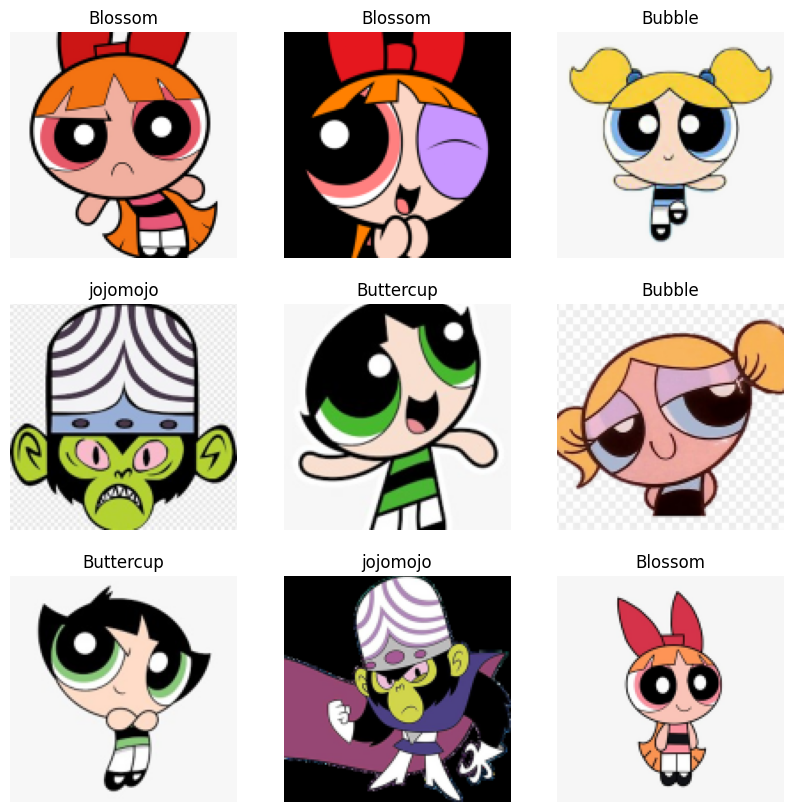

In [43]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title(class_names[labels[i]])

        plt.axis("off")



# **CNN MODEL BUILDING**

In [44]:
model = models.Sequential([

    layers.Conv2D( 32,(3,3),activation='relu',input_shape=(128,128,3)),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(4,activation='softmax')
])

# **Compile**

In [83]:
model.compile( optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [84]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# **Train the model**

In [82]:
history = model.fit(train_ds,validation_data=val_ds,epochs=10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step - accuracy: 0.8529 - loss: 0.3294 - val_accuracy: 0.8750 - val_loss: 0.5118
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.9412 - loss: 0.1386 - val_accuracy: 0.8750 - val_loss: 0.4356
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 0.9706 - loss: 0.1497 - val_accuracy: 0.8750 - val_loss: 0.4140
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 1.0000 - loss: 0.0842 - val_accuracy: 0.6250 - val_loss: 0.7188
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step - accuracy: 0.9706 - loss: 0.0924 - val_accuracy: 0.6250 - val_loss: 0.7265
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step - accuracy: 1.0000 - loss: 0.0285 - val_accuracy: 0.8750 - val_loss: 0.3762
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 0.8750 - val_loss: 0.2050
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 1.0000 - val_loss:

# **ACCURACY GRAPH**

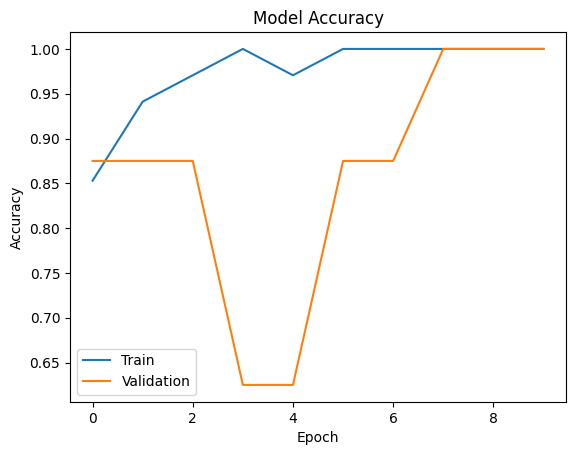

In [85]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [86]:
model.save("powerpuff_cnn.h5")

# *PREDICTION*

In [50]:
from tensorflow.keras.preprocessing import image

In [57]:
def predict_character(img_path):

    img = image.load_img(
        img_path,
        target_size=(128,128)
    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(img_array)

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)*100

    return predicted_class, confidence

# ***UI***

In [81]:
import gradio as gr
import numpy as np

# ── inference (unchanged) ─────────────────────────────────────────────────────
def classify_image(img):
    if img is None:
        return "", ""
    img_resized = img.resize((128, 128))
    img_array   = np.array(img_resized) / 255.0
    img_array   = np.expand_dims(img_array, axis=0)
    prediction      = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence      = np.max(prediction) * 100
    return predicted_class, f"{confidence:.2f}%"

# ── CSS ───────────────────────────────────────────────────────────────────────
CSS = """
@import url('https://fonts.googleapis.com/css2?family=Fredoka+One&family=Nunito:wght@400;700;800&display=swap');

/* reset gradio shell */
.gradio-container { background: #08081a !important; min-height: 100vh; padding: 0 !important; }
footer { display: none !important; }

/* ── outer app card ── */
#ppg-app {
    width: 860px;
    margin: 28px auto 0;
    background: #08081a;
    border: 1px solid #1c1c44;
    border-radius: 20px;
    overflow: hidden;
    font-family: 'Nunito', sans-serif;
}

/* ── header ── */
#ppg-app .ppg-hdr {
    background: #0d0d26;
    padding: 28px 36px 20px;
    text-align: center;
    border-bottom: 1px solid #1c1c40;
}
#ppg-app .ppg-title {
    font-family: 'Fredoka One', cursive;
    font-size: 36px;
    letter-spacing: 1px;
    background: linear-gradient(90deg,#ff6eb4 0%,#a67aff 40%,#5ec9ff 72%,#5effa0 100%);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    background-clip: text; display: inline-block;
}
#ppg-app .ppg-sub {
    color: #5a5a90; font-size: 11px; letter-spacing: 3px;
    text-transform: uppercase; margin-top: 4px;
}
#ppg-app .ppg-badges {
    display: flex; justify-content: center; gap: 28px; margin-top: 16px;
}
#ppg-app .ppg-badge { display: flex; flex-direction: column; align-items: center; gap: 5px; }
#ppg-app .ppg-circle {
    width: 52px; height: 52px; border-radius: 50%;
    display: flex; align-items: center; justify-content: center;
    font-size: 24px; border: 2px solid rgba(255,255,255,0.06);
}
#ppg-app .c-bl { background: #3a0f22; }
#ppg-app .c-bb { background: #0d2638; }
#ppg-app .c-bt { background: #0d2e14; }
#ppg-app .ppg-bname {
    font-size: 10px; font-weight: 800; letter-spacing: 2px; text-transform: uppercase;
}
#ppg-app .n-bl { color: #ff6eb4; }
#ppg-app .n-bb { color: #5ec9ff; }
#ppg-app .n-bt { color: #5effa0; }

/* ── two-column body ── */
#ppg-app .ppg-body {
    display: flex;
    min-height: 500px;
}
#ppg-app .ppg-col-l {
    width: 400px; min-width: 400px;
    padding: 22px 22px 22px 24px;
    border-right: 1px solid #141432;
    display: flex; flex-direction: column; gap: 14px;
}
#ppg-app .ppg-col-r {
    flex: 1;
    padding: 22px 24px 22px 22px;
    display: flex; flex-direction: column; gap: 12px;
}

/* ── section labels ── */
#ppg-app .slabel {
    font-size: 10px; font-weight: 800;
    letter-spacing: 2.5px; text-transform: uppercase;
    display: flex; align-items: center; gap: 6px; flex-shrink: 0;
}
#ppg-app .s-pink  { color: #ff6eb4; }
#ppg-app .s-blue  { color: #5ec9ff; }
#ppg-app .s-green { color: #5effa0; }

/* ── upload component ── */
#ppg-upload {
    flex: 1;
    min-height: 0;
}
#ppg-upload > .wrap,
#ppg-upload > div > .wrap {
    background: #0b0b22 !important;
    border: 1.5px dashed #28285a !important;
    border-radius: 14px !important;
    height: 100% !important;
    min-height: 260px !important;
    transition: border-color 0.2s !important;
}
#ppg-upload > .wrap:hover,
#ppg-upload > div > .wrap:hover { border-color: #ff6eb4 !important; }
#ppg-upload svg                  { color: #32328a !important; }
#ppg-upload .upload-text         { color: #32328a !important; }
#ppg-upload label                { display: none !important; }

/* ── detect button ── */
#ppg-btn {
    flex-shrink: 0;
}
#ppg-btn button {
    width: 100% !important;
    padding: 13px 0 !important;
    border-radius: 30px !important;
    border: none !important;
    font-family: 'Fredoka One', cursive !important;
    font-size: 17px !important;
    letter-spacing: 1.5px !important;
    color: #fff !important;
    background: linear-gradient(90deg,#cc1f55,#7722cc,#1177cc) !important;
    cursor: pointer !important;
}
#ppg-btn button:hover { opacity: 0.85 !important; }

/* ── result textboxes ── */
#ppg-char textarea, #ppg-char input,
#ppg-conf textarea, #ppg-conf input {
    background: #0b0b22 !important;
    border: 1px solid #1c1c3c !important;
    border-radius: 12px !important;
    color: #ffffff !important;
    font-family: 'Fredoka One', cursive !important;
    font-size: 22px !important;
    padding: 14px 16px !important;
    box-shadow: none !important;
}
#ppg-char label, #ppg-conf label {
    font-size: 10px !important; font-weight: 800 !important;
    letter-spacing: 2.5px !important; text-transform: uppercase !important;
    color: #303060 !important; font-family: 'Nunito', sans-serif !important;
    margin-bottom: 5px !important;
}
#ppg-char .block, #ppg-conf .block { background: transparent !important; border: none !important; padding: 0 !important; }

/* ── probability bars ── */
#ppg-app .prob-bars { display: flex; flex-direction: column; gap: 8px; }
#ppg-app .prob-row  { display: flex; flex-direction: column; gap: 3px; }
#ppg-app .prob-meta {
    display: flex; justify-content: space-between;
    font-size: 10px; font-weight: 800;
    letter-spacing: 1.5px; text-transform: uppercase;
    font-family: 'Nunito', sans-serif;
}
#ppg-app .prob-track { height: 6px; background: #141430; border-radius: 3px; overflow: hidden; }
#ppg-app .prob-fill  { height: 100%; border-radius: 3px; transition: width 0.5s ease; }
#ppg-app .f-pink  { background: #ff6eb4; width: 0%; }
#ppg-app .f-blue  { background: #5ec9ff; width: 0%; }
#ppg-app .f-green { background: #5effa0; width: 0%; }

/* ── footer ── */
#ppg-app .ppg-ftr {
    background: #060614;
    border-top: 1px solid #10102a;
    padding: 11px 26px;
    display: flex; justify-content: space-between; align-items: center;
}
#ppg-app .ppg-ftr span { font-family: 'Nunito', sans-serif; font-size: 11px; }
#ppg-app .ppg-ftr .fl { color: #22224a; letter-spacing: 1px; }
#ppg-app .ppg-ftr .fr { color: #3a1a70; font-weight: 800; letter-spacing: 3px; text-transform: uppercase; }
"""

# ── UI ────────────────────────────────────────────────────────────────────────
with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:

    with gr.Column(elem_id="ppg-app"):

        # ── Header (pure HTML, no Gradio components) ──────────────────────
        gr.HTML("""
        <div class="ppg-hdr">
          <div class="ppg-title">PowerPuff Girls Detector</div>
          <div class="ppg-sub">Powered by Chemical X &amp; Deep Learning</div>
          <div class="ppg-badges">
            <div class="ppg-badge">
              <div class="ppg-circle c-bl">🌸</div>
              <span class="ppg-bname n-bl">Blossom</span>
            </div>
            <div class="ppg-badge">
              <div class="ppg-circle c-bb">🫧</div>
              <span class="ppg-bname n-bb">Bubbles</span>
            </div>
            <div class="ppg-badge">
              <div class="ppg-circle c-bt">💪</div>
              <span class="ppg-bname n-bt">Buttercup</span>
            </div>
          </div>
        </div>
        """)

        # ── Body: use gr.Row + gr.Column so Gradio owns the flex layout ──
        with gr.Row(elem_classes=["ppg-body"]):

            # LEFT column
            with gr.Column(elem_classes=["ppg-col-l"]):

                gr.HTML('<div class="slabel s-pink">&#x2B06;&nbsp; Upload Character Image</div>')

                image_input = gr.Image(
                    type="pil",
                    label=None,
                    elem_id="ppg-upload",
                )

                predict_btn = gr.Button(
                    "✨   Detect Character   ✨",
                    elem_id="ppg-btn",
                )

            # RIGHT column
            with gr.Column(elem_classes=["ppg-col-r"]):

                gr.HTML('<div class="slabel s-blue">&#11044;&nbsp; Detection Result</div>')

                character_output = gr.Textbox(
                    label="Predicted Character",
                    placeholder="—",
                    interactive=False,
                    elem_id="ppg-char",
                )

                confidence_output = gr.Textbox(
                    label="Confidence Score",
                    placeholder="—",
                    interactive=False,
                    elem_id="ppg-conf",
                )

                gr.HTML("""
                <div class="slabel s-green" style="margin-top:6px;">&#9650;&nbsp; All Probabilities</div>
                <div class="prob-bars">
                  <div class="prob-row">
                    <div class="prob-meta">
                      <span class="n-bl">Blossom</span>
                      <span class="n-bl" id="pct-blossom">—</span>
                    </div>
                    <div class="prob-track">
                      <div class="prob-fill f-pink" id="bar-blossom"></div>
                    </div>
                  </div>
                  <div class="prob-row">
                    <div class="prob-meta">
                      <span class="n-bb">Bubbles</span>
                      <span class="n-bb" id="pct-bubbles">—</span>
                    </div>
                    <div class="prob-track">
                      <div class="prob-fill f-blue" id="bar-bubbles"></div>
                    </div>
                  </div>
                  <div class="prob-row">
                    <div class="prob-meta">
                      <span class="n-bt">Buttercup</span>
                      <span class="n-bt" id="pct-buttercup">—</span>
                    </div>
                    <div class="prob-track">
                      <div class="prob-fill f-green" id="bar-buttercup"></div>
                    </div>
                  </div>
                </div>
                """)

        # ── Footer (pure HTML) ────────────────────────────────────────────
        gr.HTML("""
        <div class="ppg-ftr">
          <span class="fl">Sugar &bull; Spice &bull; Everything Nice</span>
          <span class="fr">Chemical X</span>
        </div>
        """)

    # ── Event wiring ──────────────────────────────────────────────────────
    predict_btn.click(
        fn=classify_image,
        inputs=image_input,
        outputs=[character_output, confidence_output],
    )

    # Animate probability bars after each result
    confidence_output.change(
        fn=None,
        inputs=[character_output, confidence_output],
        outputs=None,
        js="""
        (char, conf_str) => {
            const conf   = parseFloat(conf_str) || 0;
            const rest   = 100 - conf;
            const second = parseFloat((rest * 0.62).toFixed(1));
            const third  = parseFloat((rest - second).toFixed(1));
            const c      = (char || '').toLowerCase();
            const vals   = {};
            if      (c.includes('blossom'))   { vals.blossom=conf;   vals.bubbles=second; vals.buttercup=third; }
            else if (c.includes('bubbles'))   { vals.bubbles=conf;   vals.blossom=second; vals.buttercup=third; }
            else if (c.includes('buttercup')) { vals.buttercup=conf; vals.blossom=second; vals.bubbles=third;  }
            else                              { vals.blossom=0; vals.bubbles=0; vals.buttercup=0; }
            for (const name of ['blossom','bubbles','buttercup']) {
                const b = document.getElementById('bar-' + name);
                const p = document.getElementById('pct-' + name);
                if (b) b.style.width = (vals[name] || 0) + '%';
                if (p) p.textContent = (vals[name] || 0).toFixed(1) + '%';
            }
        }
        """,
    )

demo.launch(share=True)

/tmp/ipykernel_1153/3308506340.py:186: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:
/tmp/ipykernel_1153/3308506340.py:186: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, theme=gr.themes.Base()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f732073ba33da6dd6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
